In [5]:
import pandas as pd

df = pd.read_csv("C:\\Users\\prust\\OneDrive\\Desktop\\codebase\\student dropout\\data\\Dropout (1).csv")
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [12]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)
df['target'] = df[['target_dropout', 'target_enrolled', 'target_graduate']].idxmax(axis=1)
df['target'] = df['target'].map({
    'target_dropout': 0,
    'target_enrolled': 1,
    'target_graduate': 2
})

Index(['marital status', 'application mode', 'application order', 'course',
       'daytime/evening attendance', 'previous qualification',
       'previous qualification (grade)', 'nacionality',
       'mother's qualification', 'father's qualification',
       'mother's occupation', 'father's occupation', 'admission grade',
       'displaced', 'educational special needs', 'debtor',
       'tuition fees up to date', 'gender', 'scholarship holder',
       'age at enrollment', 'international',
       'curricular units 1st sem (credited)',
       'curricular units 1st sem (enrolled)',
       'curricular units 1st sem (evaluations)',
       'curricular units 1st sem (approved)',
       'curricular units 1st sem (grade)',
       'curricular units 1st sem (without evaluations)',
       'curricular units 2nd sem (credited)',
       'curricular units 2nd sem (enrolled)',
       'curricular units 2nd sem (evaluations)',
       'curricular units 2nd sem (approved)',
       'curricular units 2nd s

In [13]:
df = df.drop(['target_dropout', 'target_enrolled', 'target_graduate'], axis=1)
print(df['target'].value_counts())

target
2    2209
0    1421
1     794
Name: count, dtype: int64


In [14]:
X = df.drop("target", axis=1)
y = df["target"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression
import pickle

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

pickle.dump(log_model, open("../models/logistic.pkl", "wb"))

c:\Users\prust\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

pickle.dump(rf_model, open("../models/rf.pkl", "wb"))

In [18]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_res, y_res = sm.fit_resample(X_train, y_train)

rf_bal = RandomForestClassifier()
rf_bal.fit(X_res, y_res)

pickle.dump(rf_bal, open("../models/rf_bal.pkl", "wb"))

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=4)
dt_model.fit(X_train, y_train)

pickle.dump(dt_model, open("../models/dt.pkl", "wb"))

In [20]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

pickle.dump(xgb_model, open("../models/xgb.pkl", "wb"))

c:\Users\prust\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:38:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [21]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier()
lgb_model.fit(X_train, y_train)

pickle.dump(lgb_model, open("../models/lgb.pkl", "wb"))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000510 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1280
[LightGBM] [Info] Number of data points in the train set: 3539, number of used features: 36
[LightGBM] [Info] Start training from score -1.163999
[LightGBM] [Info] Start training from score -1.705455
[LightGBM] [Info] Start training from score -0.681070


In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

pickle.dump(kmeans, open("../models/kmeans.pkl", "wb"))

c:\Users\prust\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


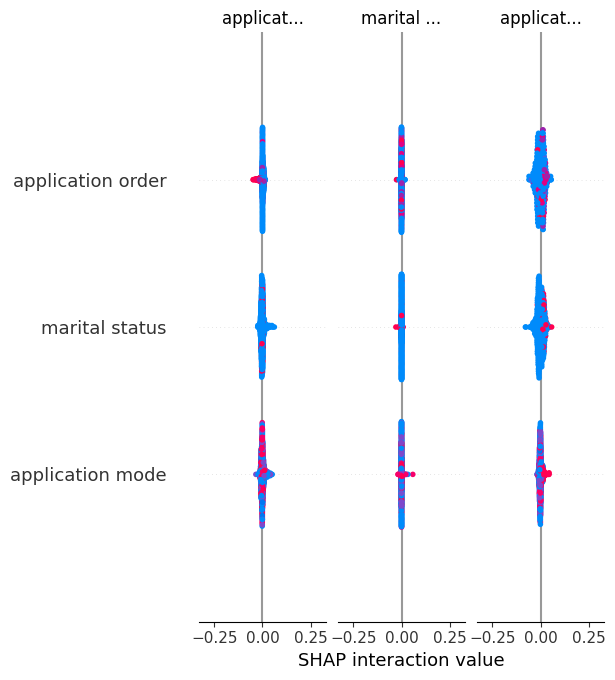

In [23]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("../static/shap.png")

In [24]:
import pickle

pickle.dump(X.columns.tolist(), open("../models/columns.pkl", "wb"))

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models_list = {
    "Logistic": log_model,
    "Random Forest": rf_model,
    "Balanced RF": rf_bal,
    "Decision Tree": dt_model,
    "XGBoost": xgb_model,
    "LightGBM": lgb_model
}

names = []
scores = []

for name, model in models_list.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    names.append(name)
    scores.append(acc)

plt.figure()
plt.bar(names, scores)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.savefig("../static/accuracy.png")
plt.close()

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_model.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.savefig("../static/confusion.png")
plt.close()

In [28]:
import numpy as np

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top Features")
plt.savefig("../static/importance.png")
plt.close()